# Physical benchmarks: radiation pressure

In this notebook we benchmark ``atomsmltr`` simulations on simple physical examples. We focus on the effect of radiation pressure.

## Formulaes and orders of magnitude

### Radiation pressure

We consider radiation pressure for an atom of mass $m$, a laser of wavenumber $k$ and a transition of natural linewidth $\Gamma$. It takes the form: 

$$
F = \hbar k \frac{\Gamma}{2} \frac{s}{1+s},
$$

with $s$ the saturation parameter, given by:

$$
s = \frac{I}{I_\mathrm{sat}} \frac{1}{1 + (2\delta/\Gamma)^2}
$$

where $I_\mathrm{sat}$ is the transition saturation intensity, and $\delta$ the laser detuning with respect to the atomic transition. We consider the limit $s\ll 1$ so that the radiation pressures of independent lasers can be summed up. 

### Acceleration of an atom at rest

We introduce the typical acceleration due to radiation pressure $\alpha$, defined as:

$$
\alpha = \frac{\hbar k}{m}\frac{\Gamma}{2}
$$

We consider a laser propagating along $+x$ and an atom initially at rest at $x=0$. In the limit where $s\ll 1$, applying Newton's law of motion we obtain the following trajectory:

$$ 
\left\{
\begin{array}{lr}
\ddot{x}(t) = \alpha s\\
\dot{x}(t) = \alpha s t\\
x(t) = \frac{1}{2} \alpha s t^2
\end{array}
\right. 
$$

This is valid for short times, that is when the effect of Doppler detuning due to the speed of the atom is negligible. Formally, this means that $\Delta_\mathrm{Doppler} \equiv k\dot{x} \ll \Gamma$. This yields:

$$
t \ll \frac{2m s}{\hbar k^2}
$$

We introduce a typical time $\tau$:

$$
\tau = \frac{2m}{\hbar k^2}
$$

### Doppler friction in a 1D Molasse

Now if we consider two counter-propagating beams, in the limit where $kv \ll \Gamma$, the radiation pressure can be approximated by a friction force :

$$
F_\mathrm{rad} = -m\gamma v
$$

with

$$
\gamma = -\frac{\hbar k^2 }{m} s_0 \frac{2 \delta \Gamma}{\delta^2 + \Gamma^2 / 4} 
$$

where $s_0 = I / I_\mathrm{sat}$. In this case, an atom with an initial speed $v_0$ is slowed as $v(t) = v_0 \exp(-\gamma t)$

### Order of magnitude for the main transition of ytterbium

Let's give the values of $\alpha$ and $\tau$ for the main transition (399nm) of Ytterbium :

In [10]:
# imports
from atomsmltr.atoms import Ytterbium
import scipy.constants as csts

# parameters
atom = Ytterbium()
transition = atom.trans["main"]

# compute
alpha = csts.hbar * transition.k * transition.Gamma / 2 / atom.mass
tau = 2 * atom.mass / csts.hbar / transition.k ** 2
v_friction = transition.Gamma / transition.k

# display
print(f"+ atom mass    : {atom.mass:.3g} kg")
print(f"+ transition Γ : 2π x {transition.Gamma / 2 / csts.pi * 1e-6:.2f} MHz")
print(f"+ transition λ : {transition.wavelength * 1e9:.2f} nm")
print(f"+ transition k : {transition.k * 1e-9:.3f} nm^-1")
print("")
print(f"> acceleration α : {alpha:.2e} m/s^2")
print(f"> recoil speed   : {csts.hbar * transition.k / atom.mass * 1e3:.2f} mm/s")
print(f"> typc. time τ   : {tau * 1e6:.1f} µs")
print(f"> typc. speed v  : {v_friction:.1f} m/s")


+ atom mass    : 2.89e-25 kg
+ transition Γ : 2π x 28.90 MHz
+ transition λ : 398.91 nm
+ transition k : 0.016 nm^-1

> acceleration α : 5.22e+05 m/s^2
> recoil speed   : 5.75 mm/s
> typc. time τ   : 22.1 µs
> typc. speed v  : 11.5 m/s


## Test #1 : initial acceleration of an atom at rest

We consider the case of an atom initially at rest, at short times - _i.e_, when the change of detuning due to the Doppler effect is still negligible. We check that the initial acceleration is consistent with the analytical formula.

────────
| main |
────────
. Parameters :
  ├── λ : 398.91 nm
  ├── Γ : 2π × 2.89e+07 Hz
  ├── Isat : 59.51 mw/cm²
  ├── Doppler temp. : 6.93e-04 K
  └── lande factor g : 1.035




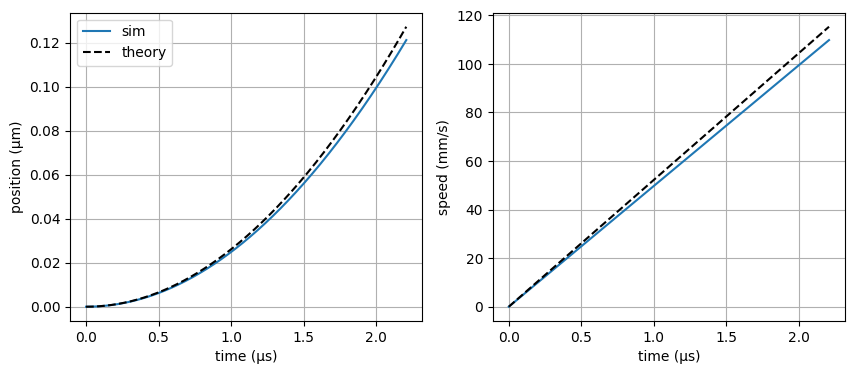

In [2]:
# - import packages
from atomsmltr.atoms import Ytterbium
from atomsmltr.environment.lasers import PlaneWaveLaserBeam
from atomsmltr.simulation import Configuration, RK4

import matplotlib.pyplot as plt
import numpy as np

# - init config
# atom
atom = Ytterbium()
transition = atom.trans["main"]
transition.print_info()
# laser
s = 0.1
laser = PlaneWaveLaserBeam(
    wavelength=transition.wavelength, direction=(1, 0, 0), tag="399"
)
laser.set_power_from_I(s * transition.Isat)
# config
config = Configuration(atom=atom) + laser
config.add_atomlight_coupling("399", "main", detuning=0)  # resonant laser
# simulator
sim = RK4(config)

# - simulate
# physical parameters
alpha = csts.hbar * transition.k * transition.Gamma / 2 / atom.mass
tau = 2 * atom.mass / csts.hbar / transition.k**2
# simulation parameters
t = np.linspace(0, s * tau, 1_000)
u0 = np.zeros(6)
# run
res = sim.integrate(u0, t)

# - plot results
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(res.t * 1e6, res.y[0, :] * 1e6, label="sim")
ax[0].plot(res.t * 1e6, 0.5 * s * alpha * res.t**2 * 1e6, "--k", label="theory")
ax[0].set_ylabel("position (µm)")
ax[0].legend()
ax[1].plot(res.t * 1e6, res.y[3, :] * 1e3)
ax[1].plot(res.t * 1e6, s * alpha * res.t * 1e3, "--k")
ax[1].set_ylabel("speed (mm/s)")

for cax in ax:
    cax.grid()
    cax.set_xlabel("time (µs)")
plt.show()

Let's vary the saturation parameter

In [3]:
s_list = np.logspace(-5, -1, 50)
v0_sim = []

for s in s_list:
    # update laser power
    laser.set_power_from_I(s * transition.Isat)
    config.update_objects(laser)
    sim.config = config
    # run simulation
    t = np.linspace(0, 0.01 * s * tau, 1_000)
    u0 = np.zeros(6)
    res = sim.integrate(u0, t)
    # fit
    p = np.polyfit(res.t, res.y[3,:],deg=1)
    v0_sim.append(p[0])

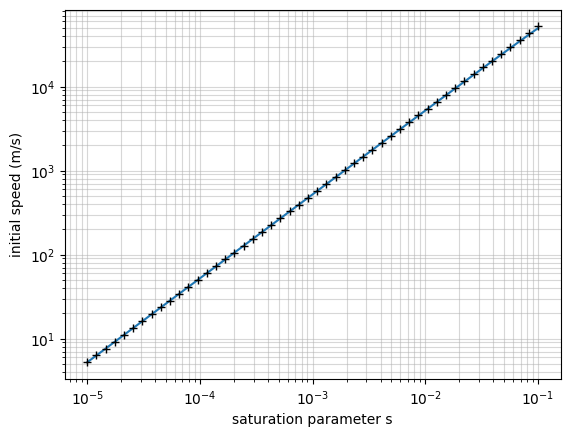

In [6]:
v0_sim = np.asanyarray(v0_sim)
v0_th = alpha * s_list

plt.figure()
plt.plot(s_list, v0_sim)
plt.plot(s_list, v0_th, '+k')
plt.loglog()
plt.grid(which='both', alpha=0.5)
plt.xlabel("saturation parameter s")
plt.ylabel("initial speed (m/s)")
plt.show()

And now let's change the detuning

In [7]:
s = 0.01
laser.set_power_from_I(s * transition.Isat)
config.update_objects(laser)

delta_list = np.linspace(0, 5, 100)  # in units of Gamma
v0_sim = []

for delta in delta_list:
    # update laser power
    config.reset_atomlight_coupling()
    config.add_atomlight_coupling("399", "main", detuning=delta*transition.Gamma) 
    sim.config = config
    # run simulation
    t = np.linspace(0, 0.01 * s * tau, 1_000)
    u0 = np.zeros(6)
    res = sim.integrate(u0, t)
    # fit
    p = np.polyfit(res.t, res.y[3,:],deg=1)
    v0_sim.append(p[0])


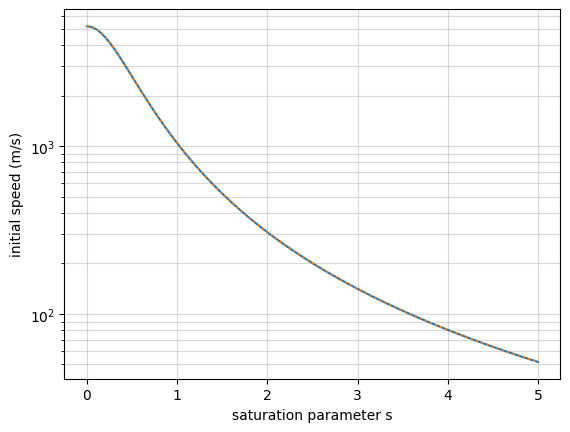

In [8]:
v0_sim = np.asanyarray(v0_sim)
v0_th = alpha * s / (1 + 4 * delta_list ** 2)

plt.figure()
plt.plot(delta_list, v0_sim)
plt.plot(delta_list, v0_th, ':')
plt.semilogy()
plt.grid(which='both', alpha=0.5)
plt.xlabel("saturation parameter s")
plt.ylabel("initial speed (m/s)")
plt.show()

## Test #2 : Doppler friction

We now consider an atom with initial speed $v_0 \ll \Gamma / k$ in a 1D Molasse. For an ytterbium atom on the main transition (399nm), the typical speed is $\Gamma / k \approx 11\,\mathrm{m/s}$.

────────
| main |
────────
. Parameters :
  ├── λ : 398.91 nm
  ├── Γ : 2π × 2.89e+07 Hz
  ├── Isat : 59.51 mw/cm²
  ├── Doppler temp. : 6.93e-04 K
  └── lande factor g : 1.035




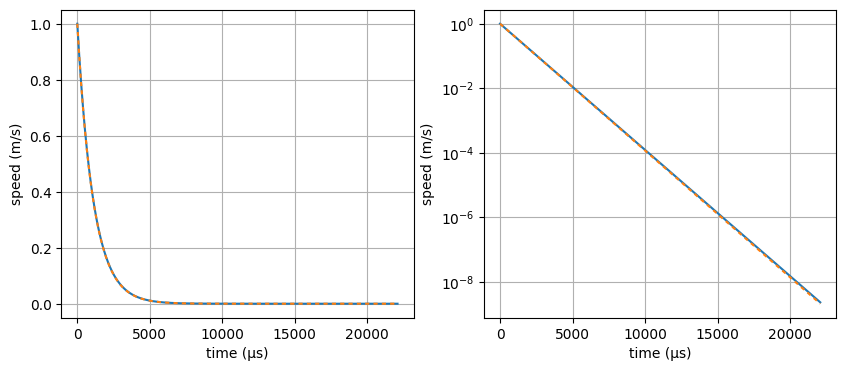

In [26]:
# - init config
# atom
atom = Ytterbium()
transition = atom.trans["main"]
transition.print_info()
# lasers
s = 0.01
laser_1 = PlaneWaveLaserBeam(
    wavelength=transition.wavelength, direction=(1, 0, 0), tag="399+"
)
laser_2 = PlaneWaveLaserBeam(
    wavelength=transition.wavelength, direction=(-1, 0, 0), tag="399-"
)
laser_1.set_power_from_I(s * transition.Isat)
laser_2.set_power_from_I(s * transition.Isat)

# config
delta = -0.5 * transition.Gamma
config = Configuration(atom=atom) + laser_1 + laser_2
config.add_atomlight_coupling("399+", "main", detuning=delta)
config.add_atomlight_coupling("399-", "main", detuning=delta)

# simulator
sim = RK4(config)

# - simulate
# physical parameters
k = transition.k
Γ = transition.Gamma
δ = delta
m = atom.mass
gamma = - csts.hbar * k ** 2 / m * s * δ * Γ / (δ ** 2 + Γ ** 2 / 4)
tau = 1 / gamma
# simulation parameters
v0 = 1
t = np.linspace(0, 20 * tau, 1_000)
u0 = np.zeros(6)
u0[3] = v0

# run
res = sim.integrate(u0, t)

# - plot results
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for cax in ax:
    cax.plot(res.t * 1e6, res.y[3, :], label="sim")
    cax.plot(res.t * 1e6, v0 * np.exp(- gamma * res.t), label="sim", dashes=[2,2])
    cax.grid()
    cax.set_xlabel("time (µs)")
    cax.set_ylabel("speed (m/s)")
ax[1].set_yscale("log")
plt.show()